In [ ]:
import sys
from pathlib import Path

def find_project_root():
    current = Path().resolve()
    for parent in [current] + list(current.parents):
        if (parent / "config" / "paths.py").exists():
            return parent
    raise FileNotFoundError("프로젝트 루트를 찾을 수 없음")

sys.path.append(str(find_project_root()))
from config.paths import PROJECT_ROOT, DATA_DIR, OUTPUTS_DIR, MODELS_DIR

# Phase 1-B · YOLOv11s 결함 검출 모델 재학습

본 노트북은 Phase 1-B 에서 v8n(`paintguard_v1`) 모델을 **YOLOv11s** 로 교체 재학습한 결과를 분석한다.

## 변경 사항 (v8n → v11s)
- 아키텍처: **YOLOv8n (3.0M params)** → **YOLOv11s (9.4M params, +3.1배)**
- 학습 epoch: 17 (early stop) → **20 (전 epoch 완주)**
- 학습 시간: ≈2시간 → **2.36시간 (141.6분)**
- 기타 하이퍼파라미터 (batch=16, imgsz=640, AdamW lr=0.001, hsv+fliplr) 동일

## 원칙
- `yolo_runs/paintguard_v1/` (v8n) 은 **절대 수정하지 않음** — 이 노트북은 `paintguard_v11s/` 만 참조.
- `yolo_inference_results.csv` 는 v11s 추론 결과로 **덮어쓰기** → Phase 2 프로파일 매핑의 입력 갱신.


## 1. 환경 확인 및 한글 폰트 설정

In [1]:
import os
import sys
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import rcParams

# 한글 폰트 (Windows)
rcParams['font.family'] = 'Malgun Gothic'
rcParams['axes.unicode_minus'] = False
rcParams['figure.dpi'] = 100

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

PROJECT_DIR = Path('C:/Users/user/Desktop/PROJ2')
RUN_DIR = PROJECT_DIR / 'yolo_runs' / 'paintguard_v11s'
IMG_DIR = PROJECT_DIR / 'track_a_images' / 'images'
LBL_DIR = PROJECT_DIR / 'track_a_images' / 'labels'

print('Python       :', sys.version.split()[0])
print('numpy        :', np.__version__)
print('pandas       :', pd.__version__)
print('RUN_DIR      :', RUN_DIR)
print('RUN_DIR 존재 :', RUN_DIR.exists())


Python       : 3.12.0
numpy        : 2.4.4
pandas       : 3.0.2
RUN_DIR      : C:\Users\user\Desktop\PROJ2\yolo_runs\paintguard_v11s
RUN_DIR 존재 : True


## 2. 데이터 사전 확인

- train 800 / val 200 이미지
- 클래스 8종 (SCR / DNT / PBB / PDR / DST / ORG / CRK / GAP)
- 일부 이미지는 빈 라벨 (배경 샘플)

In [2]:
CLASS_NAMES = [
    'scratch', 'dent', 'paint_bubble', 'paint_drip',
    'dust', 'orange_peel', 'crack', 'gap_fault',
]
CLASS_KOR = ['스크래치', '덴트', '도장기포', '도장흘림',
             '이물질', '오렌지필', '크랙', 'Gap불량']
DEFECT_CODE = ['SCR', 'DNT', 'PBB', 'PDR', 'DST', 'ORG', 'CRK', 'GAP']
SEVERITY = {
    'SCR': 'MINOR', 'DNT': 'MAJOR', 'PBB': 'MINOR', 'PDR': 'MINOR',
    'DST': 'MINOR', 'ORG': 'MINOR', 'CRK': 'CRITICAL', 'GAP': 'CRITICAL',
}
SEV_COLOR = {'CRITICAL': '#E74C3C', 'MAJOR': '#F39C12', 'MINOR': '#3498DB'}

# 이미지/라벨 개수
train_imgs = sorted((IMG_DIR / 'train').glob('*.jpg'))
val_imgs   = sorted((IMG_DIR / 'val').glob('*.jpg'))
train_lbls = sorted((LBL_DIR / 'train').glob('*.txt'))
val_lbls   = sorted((LBL_DIR / 'val').glob('*.txt'))

print(f'train 이미지 : {len(train_imgs)}')
print(f'val   이미지 : {len(val_imgs)}')
print(f'train 라벨   : {len(train_lbls)}')
print(f'val   라벨   : {len(val_lbls)}')

# 클래스별 bbox 수 (train + val)
def count_bbox(lbl_dir: Path) -> dict:
    cnt = {i: 0 for i in range(8)}
    empty = 0
    for f in lbl_dir.glob('*.txt'):
        rows = [l.strip() for l in f.read_text(encoding='utf-8').splitlines() if l.strip()]
        if not rows:
            empty += 1
            continue
        for r in rows:
            cid = int(r.split()[0])
            cnt[cid] = cnt.get(cid, 0) + 1
    return cnt, empty

train_cnt, train_empty = count_bbox(LBL_DIR / 'train')
val_cnt,   val_empty   = count_bbox(LBL_DIR / 'val')

bbox_df = pd.DataFrame({
    'class_id': list(range(8)),
    '한글명':   CLASS_KOR,
    '코드':     DEFECT_CODE,
    '심각도':   [SEVERITY[c] for c in DEFECT_CODE],
    'train':    [train_cnt[i] for i in range(8)],
    'val':      [val_cnt[i]   for i in range(8)],
})
bbox_df['합계'] = bbox_df['train'] + bbox_df['val']
print(f'\n배경 이미지(빈 라벨) train: {train_empty} / val: {val_empty}')
print(f'bbox 총계 train: {bbox_df["train"].sum()} / val: {bbox_df["val"].sum()}')
bbox_df


train 이미지 : 800
val   이미지 : 200
train 라벨   : 800
val   라벨   : 200

배경 이미지(빈 라벨) train: 133 / val: 36
bbox 총계 train: 1044 / val: 240


,class_id,한글명,코드,심각도,train,val,합계
0,0,스크래치,SCR,MINOR,260,65,325
1,1,덴트,DNT,MAJOR,204,48,252
2,2,도장기포,PBB,MINOR,135,31,166
3,3,도장흘림,PDR,MINOR,102,14,116
4,4,이물질,DST,MINOR,118,33,151
5,5,오렌지필,ORG,MINOR,98,23,121
6,6,크랙,CRK,CRITICAL,49,5,54
7,7,Gap불량,GAP,CRITICAL,78,21,99


## 3. 학습 결과 로드 (results.csv)

20 epoch 각각의 loss / precision / recall / mAP 추이를 확인.
v11s 는 `patience=8` 이었지만 20 epoch 전체를 완주 — 마지막까지 개선 진행.

In [3]:
results_csv = RUN_DIR / 'results.csv'
rdf = pd.read_csv(results_csv)
rdf.columns = [c.strip() for c in rdf.columns]
print(f'results.csv 행 수(epoch) : {len(rdf)}')
print(f'총 학습 시간(sec)       : {rdf["time"].iloc[-1]:.1f} (= {rdf["time"].iloc[-1]/60:.1f}분)')
print(f'epoch당 평균(sec)       : {rdf["time"].diff().mean():.1f}')
rdf[['epoch', 'time',
     'train/box_loss', 'train/cls_loss',
     'val/box_loss',   'val/cls_loss',
     'metrics/precision(B)', 'metrics/recall(B)',
     'metrics/mAP50(B)',     'metrics/mAP50-95(B)']].round(4)


results.csv 행 수(epoch) : 20
총 학습 시간(sec)       : 8471.6 (= 141.2분)
epoch당 평균(sec)       : 422.4


,epoch,time,train/box_loss,train/cls_loss,val/box_loss,val/cls_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B)
0,1,445.75,1.2705,2.1262,1.3337,2.6020,0.5758,0.6934,0.6659,0.4202
1,2,875.66,1.1583,1.0612,0.9772,1.0083,0.7763,0.8174,0.8207,0.6251
2,3,1307.17,1.1322,0.9903,0.9227,0.9226,0.8002,0.8563,0.8424,0.6140
3,4,1736.54,1.1010,0.9147,0.9882,0.8741,0.8009,0.9237,0.8685,0.6267
4,5,2164.39,1.0718,0.8478,0.7782,0.6367,0.8512,0.9204,0.9001,0.7159
5,6,2591.67,1.0082,0.7747,0.7637,0.6421,0.8705,0.9345,0.9032,0.7285
6,7,3016.80,0.9279,0.7331,0.7334,0.5592,0.8501,0.9405,0.9039,0.7478
7,8,3453.59,0.9433,0.7289,0.7447,0.5325,0.8099,0.9546,0.9150,0.7326
8,9,3884.92,0.9559,0.7175,0.7950,0.5485,0.8457,0.9643,0.9298,0.7321
9,10,4312.55,0.8702,0.6691,0.6416,0.4755,0.8710,0.9524,0.9368,0.7801


## 4. best.pt 로드 및 val 평가

학습 중 저장된 best.pt 를 다시 불러와 val 200장에 대해 정식 평가를 수행한다.
결과는 `v11s_metrics` 딕셔너리에 저장하여 이후 비교에 사용.

In [4]:
from ultralytics import YOLO

best_pt = RUN_DIR / 'weights' / 'best.pt'
print(f'best.pt 크기 : {best_pt.stat().st_size / 1024**2:.1f} MB')

model_v11s = YOLO(str(best_pt))
metrics = model_v11s.val(
    data=str(PROJECT_DIR / 'data_yolo.yaml'),
    imgsz=640,
    batch=16,
    conf=0.001,
    iou=0.6,
    plots=False,
    verbose=False,
)

v11s_overall = {
    'mAP@0.5':       float(metrics.box.map50),
    'mAP@0.5:0.95':  float(metrics.box.map),
    'precision':     float(metrics.box.mp),
    'recall':        float(metrics.box.mr),
}

# per-class
v11s_per_class = []
for i, name in enumerate(CLASS_NAMES):
    v11s_per_class.append({
        'class_id':       i,
        'class_name':     name,
        '한글명':         CLASS_KOR[i],
        '코드':           DEFECT_CODE[i],
        '심각도':         SEVERITY[DEFECT_CODE[i]],
        'P':              float(metrics.box.p[i])       if i < len(metrics.box.p)       else None,
        'R':              float(metrics.box.r[i])       if i < len(metrics.box.r)       else None,
        'mAP@0.5':        float(metrics.box.ap50[i])    if i < len(metrics.box.ap50)    else None,
        'mAP@0.5:0.95':   float(metrics.box.ap[i])      if i < len(metrics.box.ap)      else None,
    })
per_class_df = pd.DataFrame(v11s_per_class)

print('--- 전체 성능 (v11s) ---')
for k, v in v11s_overall.items():
    print(f'  {k:15s} : {v:.4f}')

per_class_df.round(4)


best.pt 크기 : 18.3 MB
Ultralytics 8.4.35  Python-3.12.0 torch-2.11.0+cpu CPU (AMD Ryzen 7 3800XT 8-Core Processor)


YOLO11s summary (fused): 101 layers, 9,415,896 parameters, 0 gradients, 21.3 GFLOPs


val: Fast image access  (ping: 0.00.0 ms, read: 453.843.1 MB/s, size: 55.9 KB)


val: Scanning C:\Users\user\Desktop\PROJ2\track_a_images\labels\val.cache... 200 images, 36 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 200/200  0.0s

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 8% ╸─────────── 1/13 5.4s/it 1.6s<1:05

...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 1.2s/it 16.1s

                   all        200        240       0.94      0.998      0.987      0.866


Speed: 0.9ms preprocess, 74.2ms inference, 0.0ms loss, 0.4ms postprocess per image


--- 전체 성능 (v11s) ---
  mAP@0.5         : 0.9875
  mAP@0.5:0.95    : 0.8656
  precision       : 0.9401
  recall          : 0.9975


,class_id,class_name,한글명,코드,심각도,P,R,mAP@0.5,mAP@0.5:0.95
0,0,scratch,스크래치,SCR,MINOR,0.9895,1.0000,0.9950,0.9383
1,1,dent,덴트,DNT,MAJOR,0.9865,1.0000,0.9950,0.9818
2,2,paint_bubble,도장기포,PBB,MINOR,0.9828,1.0000,0.9950,0.9255
3,3,paint_drip,도장흘림,PDR,MINOR,0.9552,1.0000,0.9950,0.8477
4,4,dust,이물질,DST,MINOR,0.9667,1.0000,0.9950,0.9000
5,5,orange_peel,오렌지필,ORG,MINOR,0.9754,1.0000,0.9950,0.9138
6,6,crack,크랙,CRK,CRITICAL,0.8903,1.0000,0.9950,0.8931
7,7,gap_fault,Gap불량,GAP,CRITICAL,0.7742,0.9803,0.9348,0.5248


## 5. 클래스별 성능 — v8n vs v11s 비교표

- v8n 결과는 `CLAUDE.md` 에 기록된 수치를 하드코딩하여 비교.
- **CRITICAL (빨강) / MAJOR (주황) / MINOR (파랑)** 으로 심각도 구분.

In [5]:
V8N_OVERALL = {
    'mAP@0.5':      0.9931,
    'mAP@0.5:0.95': 0.8111,
    'precision':    0.9628,
    'recall':       0.9889,
}
V8N_PER_CLASS = {
    'SCR': {'P': 0.9441, 'R': 1.0000, 'mAP@0.5': 0.9936, 'mAP@0.5:0.95': 0.8739},
    'DNT': {'P': 0.9876, 'R': 1.0000, 'mAP@0.5': 0.9950, 'mAP@0.5:0.95': 0.9732},
    'PBB': {'P': 0.9748, 'R': 1.0000, 'mAP@0.5': 0.9950, 'mAP@0.5:0.95': 0.8898},
    'PDR': {'P': 0.9575, 'R': 1.0000, 'mAP@0.5': 0.9950, 'mAP@0.5:0.95': 0.7408},
    'DST': {'P': 1.0000, 'R': 0.9810, 'mAP@0.5': 0.9950, 'mAP@0.5:0.95': 0.8080},
    'ORG': {'P': 1.0000, 'R': 0.9778, 'mAP@0.5': 0.9950, 'mAP@0.5:0.95': 0.8573},
    'CRK': {'P': 0.9023, 'R': 1.0000, 'mAP@0.5': 0.9950, 'mAP@0.5:0.95': 0.7765},
    'GAP': {'P': 0.9358, 'R': 0.9524, 'mAP@0.5': 0.9815, 'mAP@0.5:0.95': 0.5695},
}

overall_cmp = pd.DataFrame({
    '지표':       list(V8N_OVERALL.keys()),
    'v8n (기존)': list(V8N_OVERALL.values()),
    'v11s (신규)':[v11s_overall[k] for k in V8N_OVERALL.keys()],
})
overall_cmp['차이(v11s-v8n)'] = (overall_cmp['v11s (신규)'] - overall_cmp['v8n (기존)']).round(4)
overall_cmp = overall_cmp.round(4)
print('=== 전체 성능 비교 ===')
print(overall_cmp.to_string(index=False))

cmp_rows = []
for row in v11s_per_class:
    code = row['코드']
    v8 = V8N_PER_CLASS[code]
    cmp_rows.append({
        'class_id':     row['class_id'],
        '한글명':       row['한글명'],
        '코드':         code,
        '심각도':       row['심각도'],
        'v8n mAP@0.5':        v8['mAP@0.5'],
        'v11s mAP@0.5':       row['mAP@0.5'],
        'Δ mAP@0.5':          round(row['mAP@0.5']      - v8['mAP@0.5'],      4),
        'v8n mAP@0.5:0.95':   v8['mAP@0.5:0.95'],
        'v11s mAP@0.5:0.95':  row['mAP@0.5:0.95'],
        'Δ mAP@0.5:0.95':     round(row['mAP@0.5:0.95'] - v8['mAP@0.5:0.95'], 4),
    })
cmp_df = pd.DataFrame(cmp_rows)

def color_delta(v: float) -> str:
    if v > 0:   return 'background-color: #D5F5E3'   # 녹
    if v < 0:   return 'background-color: #FADBD8'   # 적
    return ''

display(cmp_df.round(4)
    .style.map(color_delta, subset=['Δ mAP@0.5', 'Δ mAP@0.5:0.95']))


=== 전체 성능 비교 ===
          지표  v8n (기존)  v11s (신규)  차이(v11s-v8n)
     mAP@0.5    0.9931     0.9875       -0.0056
mAP@0.5:0.95    0.8111     0.8656        0.0545
   precision    0.9628     0.9401       -0.0227
      recall    0.9889     0.9975        0.0086


,class_id,한글명,코드,심각도,v8n mAP@0.5,v11s mAP@0.5,Δ mAP@0.5,v8n mAP@0.5:0.95,v11s mAP@0.5:0.95,Δ mAP@0.5:0.95
0,0,스크래치,SCR,MINOR,0.993600,0.995000,0.001400,0.873900,0.938300,0.064400
1,1,덴트,DNT,MAJOR,0.995000,0.995000,0.000000,0.973200,0.981800,0.008600
2,2,도장기포,PBB,MINOR,0.995000,0.995000,0.000000,0.889800,0.925500,0.035700
3,3,도장흘림,PDR,MINOR,0.995000,0.995000,0.000000,0.740800,0.847700,0.106900
4,4,이물질,DST,MINOR,0.995000,0.995000,0.000000,0.808000,0.900000,0.092000
5,5,오렌지필,ORG,MINOR,0.995000,0.995000,0.000000,0.857300,0.913800,0.056500
6,6,크랙,CRK,CRITICAL,0.995000,0.995000,0.000000,0.776500,0.893100,0.116600
7,7,Gap불량,GAP,CRITICAL,0.981500,0.934800,-0.046700,0.569500,0.524800,-0.044700


## 6. 시각화

- 클래스별 mAP@0.5 / mAP@0.5:0.95 bar chart (심각도 색상)
- v8n vs v11s 나란히 비교
- 학습 곡선 (loss / mAP / lr)

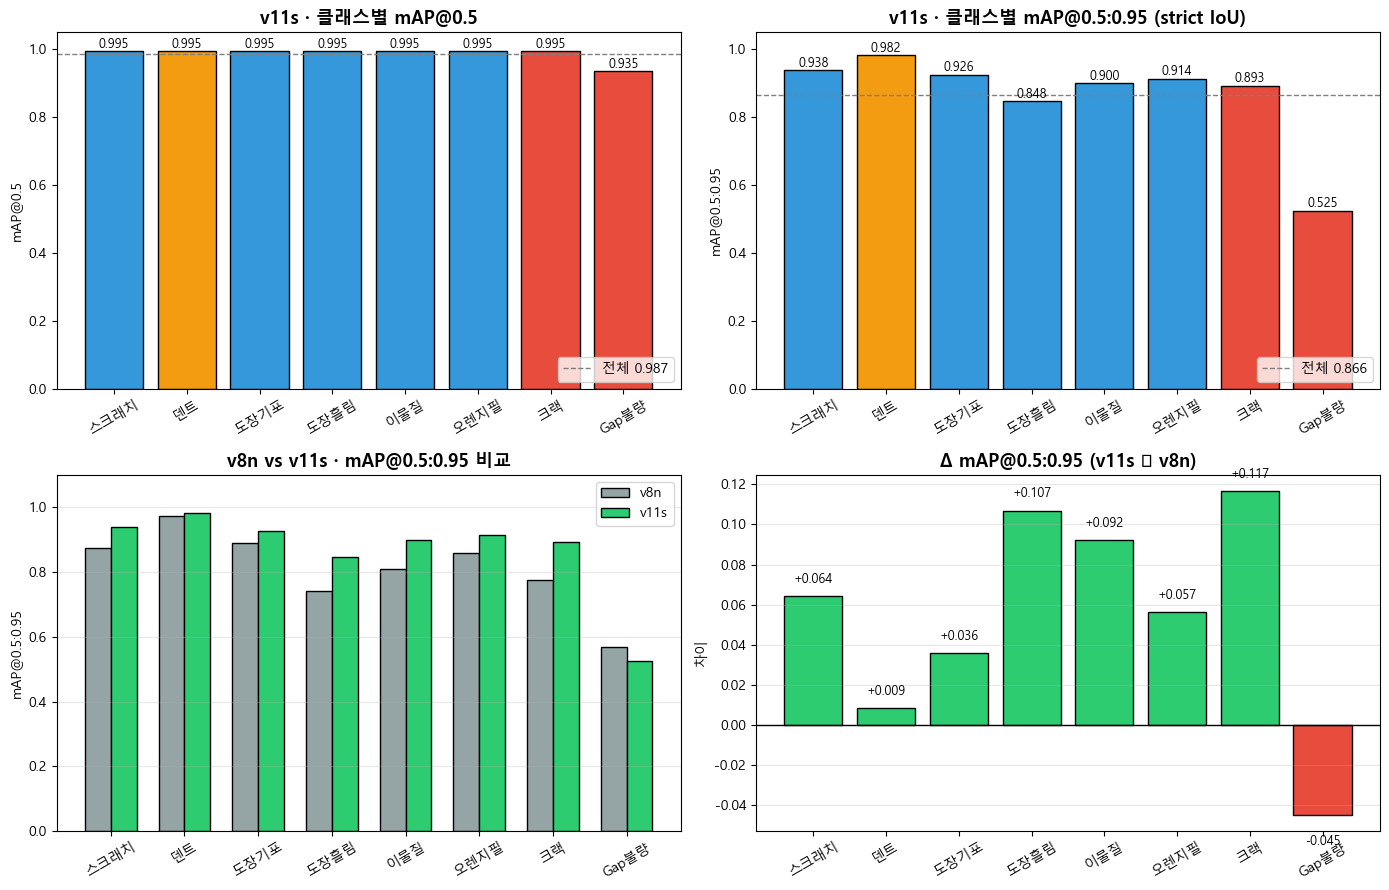

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

labels_kor = cmp_df['한글명'].tolist()
codes      = cmp_df['코드'].tolist()
bar_colors = [SEV_COLOR[SEVERITY[c]] for c in codes]

# (0,0) v11s mAP@0.5
ax = axes[0, 0]
ax.bar(labels_kor, cmp_df['v11s mAP@0.5'], color=bar_colors, edgecolor='black')
ax.set_title('v11s · 클래스별 mAP@0.5', fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.05)
ax.set_ylabel('mAP@0.5')
ax.axhline(v11s_overall['mAP@0.5'], color='gray', ls='--', lw=1, label=f'전체 {v11s_overall["mAP@0.5"]:.3f}')
ax.legend(loc='lower right')
for i, v in enumerate(cmp_df['v11s mAP@0.5']):
    ax.text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)
ax.tick_params(axis='x', rotation=30)

# (0,1) v11s mAP@0.5:0.95
ax = axes[0, 1]
ax.bar(labels_kor, cmp_df['v11s mAP@0.5:0.95'], color=bar_colors, edgecolor='black')
ax.set_title('v11s · 클래스별 mAP@0.5:0.95 (strict IoU)', fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.05)
ax.set_ylabel('mAP@0.5:0.95')
ax.axhline(v11s_overall['mAP@0.5:0.95'], color='gray', ls='--', lw=1,
           label=f'전체 {v11s_overall["mAP@0.5:0.95"]:.3f}')
ax.legend(loc='lower right')
for i, v in enumerate(cmp_df['v11s mAP@0.5:0.95']):
    ax.text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)
ax.tick_params(axis='x', rotation=30)

# (1,0) v8n vs v11s mAP@0.5:0.95 side-by-side
ax = axes[1, 0]
x = np.arange(len(labels_kor))
w = 0.35
ax.bar(x - w/2, cmp_df['v8n mAP@0.5:0.95'],  w, label='v8n',  color='#95A5A6', edgecolor='black')
ax.bar(x + w/2, cmp_df['v11s mAP@0.5:0.95'], w, label='v11s', color='#2ECC71', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(labels_kor, rotation=30)
ax.set_title('v8n vs v11s · mAP@0.5:0.95 비교', fontsize=13, fontweight='bold')
ax.set_ylabel('mAP@0.5:0.95')
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# (1,1) Δ mAP@0.5:0.95
ax = axes[1, 1]
delta = cmp_df['Δ mAP@0.5:0.95'].values
delta_colors = ['#2ECC71' if d > 0 else '#E74C3C' for d in delta]
ax.bar(labels_kor, delta, color=delta_colors, edgecolor='black')
ax.axhline(0, color='black', lw=1)
ax.set_title('Δ mAP@0.5:0.95 (v11s − v8n)', fontsize=13, fontweight='bold')
ax.set_ylabel('차이')
for i, v in enumerate(delta):
    ax.text(i, v + (0.005 if v >= 0 else -0.01), f'{v:+.3f}',
            ha='center', fontsize=9,
            va='bottom' if v >= 0 else 'top')
ax.tick_params(axis='x', rotation=30)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


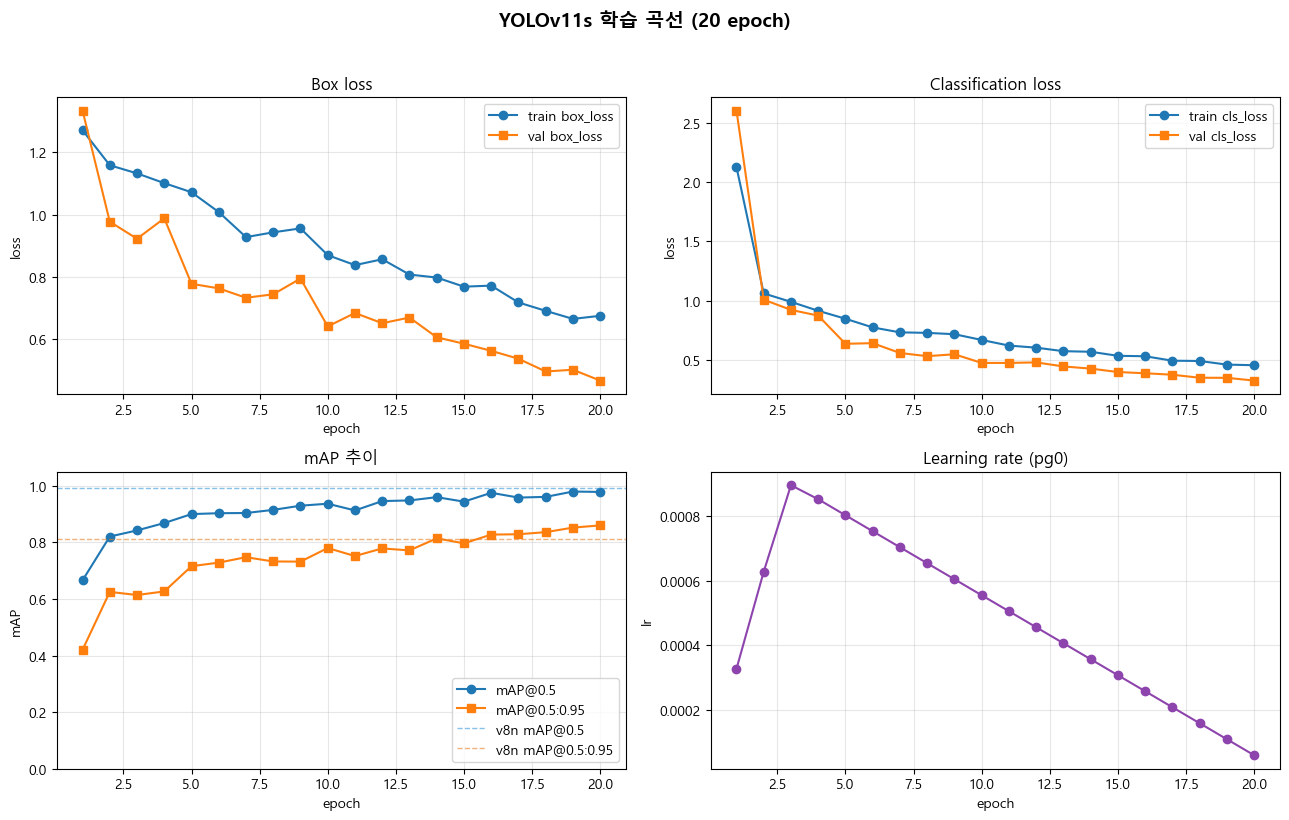

In [7]:
# 학습 곡선
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# (0,0) train/val box loss
ax = axes[0, 0]
ax.plot(rdf['epoch'], rdf['train/box_loss'], marker='o', label='train box_loss')
ax.plot(rdf['epoch'], rdf['val/box_loss'],   marker='s', label='val box_loss')
ax.set_title('Box loss')
ax.set_xlabel('epoch'); ax.set_ylabel('loss')
ax.legend(); ax.grid(alpha=0.3)

# (0,1) train/val cls loss
ax = axes[0, 1]
ax.plot(rdf['epoch'], rdf['train/cls_loss'], marker='o', label='train cls_loss')
ax.plot(rdf['epoch'], rdf['val/cls_loss'],   marker='s', label='val cls_loss')
ax.set_title('Classification loss')
ax.set_xlabel('epoch'); ax.set_ylabel('loss')
ax.legend(); ax.grid(alpha=0.3)

# (1,0) mAP50, mAP50:95
ax = axes[1, 0]
ax.plot(rdf['epoch'], rdf['metrics/mAP50(B)'],     marker='o', label='mAP@0.5')
ax.plot(rdf['epoch'], rdf['metrics/mAP50-95(B)'],  marker='s', label='mAP@0.5:0.95')
# v8n reference lines
ax.axhline(V8N_OVERALL['mAP@0.5'],      color='#3498DB', ls='--', lw=1, alpha=0.6, label='v8n mAP@0.5')
ax.axhline(V8N_OVERALL['mAP@0.5:0.95'], color='#E67E22', ls='--', lw=1, alpha=0.6, label='v8n mAP@0.5:0.95')
ax.set_title('mAP 추이')
ax.set_xlabel('epoch'); ax.set_ylabel('mAP')
ax.set_ylim(0, 1.05)
ax.legend(loc='lower right')
ax.grid(alpha=0.3)

# (1,1) learning rate
ax = axes[1, 1]
ax.plot(rdf['epoch'], rdf['lr/pg0'], marker='o', color='#8E44AD')
ax.set_title('Learning rate (pg0)')
ax.set_xlabel('epoch'); ax.set_ylabel('lr')
ax.grid(alpha=0.3)

plt.suptitle('YOLOv11s 학습 곡선 (20 epoch)', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 7. val 200장 추론 → `yolo_inference_results.csv` 재생성

Phase 2 프로파일 매핑의 입력 파일을 v11s 추론 결과로 **덮어쓴다**.

- 파일명 파싱: `{zone}_{color}_{id}.jpg` — `pearl_white`, `front_door`, `rear_door` 등 복수 토큰 대응.
- 결함 없는 이미지는 `class_id=NaN` 더미행으로 보존 → 200장 100% 커버리지 유지.

In [8]:
# 파일명 파서 ------------------------------------------------------------
KNOWN_ZONES = [
    'front_door', 'rear_door',    # 2-token
    'hood', 'trunk', 'roof', 'rocker', 'bumper', 'fender',  # 1-token
]
KNOWN_COLORS = [
    'pearl_white',   # 2-token
    'black', 'white', 'red', 'blue', 'silver', 'gray',
    'navy', 'green', 'bronze',
]


def parse_filename(stem: str) -> dict:
    '''stem 에서 zone/color/id 파싱. 복수 토큰 처리.'''
    # suffix id (마지막 _000xxx)
    parts = stem.split('_')
    img_id = parts[-1]
    rest = '_'.join(parts[:-1])     # zone_color 후보
    zone, color = None, None
    for z in KNOWN_ZONES:
        if rest.startswith(z + '_'):
            zone = z
            color_part = rest[len(z) + 1:]
            break
    if zone is None:
        # fallback: 첫 토큰 = zone
        zone = parts[0]
        color_part = '_'.join(parts[1:-1])
    for c in KNOWN_COLORS:
        if color_part == c:
            color = c
            break
    if color is None:
        color = color_part  # 그대로 저장
    return {'zone': zone, 'color': color, 'image_id': img_id}


# --- 추론 루프 -------------------------------------------------------
val_img_dir = IMG_DIR / 'val'
val_files = sorted(val_img_dir.glob('*.jpg'))
print(f'추론 대상 : {len(val_files)}장')

rows = []
detect_cnt = 0
for img_path in val_files:
    fname = img_path.name
    parsed = parse_filename(img_path.stem)
    r = model_v11s.predict(source=str(img_path), imgsz=640, conf=0.25, verbose=False)[0]

    if r.boxes is None or len(r.boxes) == 0:
        # 더미 NaN 행 (커버리지 유지)
        rows.append({
            'image_file': fname,
            **parsed,
            'class_id': np.nan, 'class_name': np.nan,
            'defect_type_code': np.nan, 'severity': np.nan,
            'conf': np.nan,
            'bbox_x1': np.nan, 'bbox_y1': np.nan,
            'bbox_x2': np.nan, 'bbox_y2': np.nan,
            'bbox_w_norm': np.nan, 'bbox_h_norm': np.nan,
            'area_norm': np.nan,
        })
        continue

    detect_cnt += 1
    W, H = r.orig_shape[1], r.orig_shape[0]
    for b in r.boxes:
        cid = int(b.cls.item())
        conf = float(b.conf.item())
        x1, y1, x2, y2 = [float(v) for v in b.xyxy[0].tolist()]
        x1n, y1n, x2n, y2n = x1/W, y1/H, x2/W, y2/H
        w_n = x2n - x1n
        h_n = y2n - y1n
        rows.append({
            'image_file':       fname,
            **parsed,
            'class_id':         float(cid),
            'class_name':       CLASS_NAMES[cid],
            'defect_type_code': DEFECT_CODE[cid],
            'severity':         SEVERITY[DEFECT_CODE[cid]],
            'conf':             round(conf, 4),
            'bbox_x1':          round(x1n, 4),
            'bbox_y1':          round(y1n, 4),
            'bbox_x2':          round(x2n, 4),
            'bbox_y2':          round(y2n, 4),
            'bbox_w_norm':      round(w_n, 4),
            'bbox_h_norm':      round(h_n, 4),
            'area_norm':        round(w_n * h_n, 6),
        })

inf_df = pd.DataFrame(rows)
total_det = inf_df['class_id'].notna().sum()
empty_img = inf_df['class_id'].isna().sum()
print(f'탐지 성공 이미지 : {detect_cnt} / {len(val_files)}')
print(f'총 탐지 bbox     : {total_det}')
print(f'더미(빈) 행      : {empty_img}')
print(f'전체 행 수       : {len(inf_df)}')

out_path = PROJECT_DIR / 'yolo_inference_results.csv'
inf_df.to_csv(out_path, index=False, encoding='utf-8-sig')
print(f'\n저장 완료 : {out_path}')
inf_df.head()


추론 대상 : 200장


탐지 성공 이미지 : 162 / 200
총 탐지 bbox     : 251
더미(빈) 행      : 38
전체 행 수       : 289

저장 완료 : C:\Users\user\Desktop\PROJ2\yolo_inference_results.csv


,image_file,zone,color,image_id,class_id,class_name,defect_type_code,severity,conf,bbox_x1,bbox_y1,bbox_x2,bbox_y2,bbox_w_norm,bbox_h_norm,area_norm
0,bumper_black_000877.jpg,bumper,black,000877,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,bumper_black_000889.jpg,bumper,black,000889,1.0,dent,DNT,MAJOR,0.9455,0.3430,0.7467,0.4216,0.8881,0.0785,0.1414,0.011102
2,bumper_black_000995.jpg,bumper,black,000995,0.0,scratch,SCR,MINOR,0.8974,0.6131,0.5425,0.6877,0.6018,0.0746,0.0593,0.004425
3,bumper_black_000995.jpg,bumper,black,000995,7.0,gap_fault,GAP,CRITICAL,0.3380,0.0403,0.7151,0.7846,0.7616,0.7443,0.0465,0.034627
4,bumper_black_000995.jpg,bumper,black,000995,7.0,gap_fault,GAP,CRITICAL,0.3093,0.3180,0.7166,1.0000,0.7605,0.6820,0.0438,0.029897


## 8. v8n vs v11s 탐지 분포 비교

같은 val 200장에 대해 v8n 과 v11s 가 **탐지한 결함의 분포**를 비교.

- v8n 분포: `CLAUDE.md` 5단계의 `_yolo_result.json` 수치를 하드코딩하여 사용.
- v11s 분포: 위에서 생성한 `inf_df` 로부터 실시간 산출.

In [9]:
# v8n 탐지 분포 (CLAUDE.md 5단계 테이블에서 전재)
V8N_ZONE_RATIO = {
    'bumper':     0.1440,   # BUMPER_F+R
    'fender':     0.1523,   # FF+RF
    'rocker':     0.1481,
    'trunk':      0.1358,
    'hood':       0.1317,
    'rear_door':  0.1111,
    'front_door': 0.0905,
    'roof':       0.0864,
}
V8N_DEFECT_RATIO = {
    'SCR': 0.2757, 'DNT': 0.1975, 'DST': 0.1317, 'PBB': 0.1276,
    'GAP': 0.0988, 'ORG': 0.0905, 'PDR': 0.0576, 'CRK': 0.0206,
    'CLP': 0.0000, 'WLD': 0.0000,
}

det = inf_df[inf_df['class_id'].notna()].copy()
total = len(det)
print(f'v11s 탐지 bbox 총수 : {total}')

# zone 분포 (v11s)
v11s_zone = (det['zone'].value_counts(normalize=True)
             .rename('v11s_ratio').to_frame().reset_index()
             .rename(columns={'index': 'zone'}))
# v8n → v11s merge
zone_cmp = pd.DataFrame({
    'zone':       list(V8N_ZONE_RATIO.keys()),
    'v8n_ratio':  list(V8N_ZONE_RATIO.values()),
})
zone_cmp = zone_cmp.merge(v11s_zone, on='zone', how='outer').fillna(0)
zone_cmp['Δ'] = (zone_cmp['v11s_ratio'] - zone_cmp['v8n_ratio']).round(4)
zone_cmp = zone_cmp.sort_values('v11s_ratio', ascending=False).round(4)
print('\n=== Zone 비율 비교 (v8n → v11s) ===')
print(zone_cmp.to_string(index=False))

# defect_type 분포
v11s_def = (det['defect_type_code'].value_counts(normalize=True)
            .rename('v11s_ratio').to_frame().reset_index()
            .rename(columns={'index': 'defect_type_code'}))
def_cmp = pd.DataFrame({
    'defect_type_code': list(V8N_DEFECT_RATIO.keys()),
    'v8n_ratio':        list(V8N_DEFECT_RATIO.values()),
})
def_cmp = def_cmp.merge(v11s_def, on='defect_type_code', how='outer').fillna(0)
def_cmp['Δ'] = (def_cmp['v11s_ratio'] - def_cmp['v8n_ratio']).round(4)
def_cmp = def_cmp.sort_values('v11s_ratio', ascending=False).round(4)
print('\n=== Defect type 비율 비교 (v8n → v11s) ===')
print(def_cmp.to_string(index=False))


v11s 탐지 bbox 총수 : 251

=== Zone 비율 비교 (v8n → v11s) ===
      zone  v8n_ratio  v11s_ratio       Δ
    rocker     0.1481      0.1633  0.0152
    fender     0.1523      0.1594  0.0071
    bumper     0.1440      0.1394 -0.0046
     trunk     0.1358      0.1315 -0.0043
      hood     0.1317      0.1275 -0.0042
 rear_door     0.1111      0.1076 -0.0035
front_door     0.0905      0.0876 -0.0029
      roof     0.0864      0.0837 -0.0027

=== Defect type 비율 비교 (v8n → v11s) ===
defect_type_code  v8n_ratio  v11s_ratio       Δ
             SCR     0.2757      0.2590 -0.0167
             DNT     0.1975      0.1912 -0.0063
             DST     0.1317      0.1355  0.0038
             PBB     0.1276      0.1235 -0.0041
             GAP     0.0988      0.1195  0.0207
             ORG     0.0905      0.0916  0.0011
             PDR     0.0576      0.0598  0.0022
             CRK     0.0206      0.0199 -0.0007
             CLP     0.0000      0.0000  0.0000
             WLD     0.0000      0.0000  0.0000

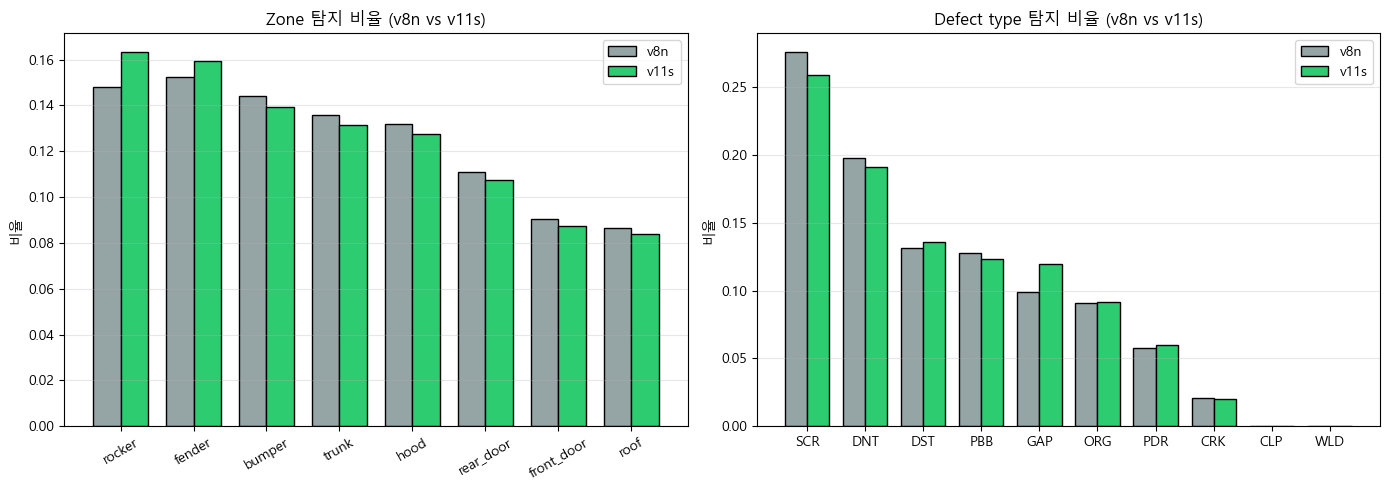

In [10]:
# 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# zone
ax = axes[0]
x = np.arange(len(zone_cmp))
w = 0.38
ax.bar(x - w/2, zone_cmp['v8n_ratio'],  w, label='v8n',  color='#95A5A6', edgecolor='black')
ax.bar(x + w/2, zone_cmp['v11s_ratio'], w, label='v11s', color='#2ECC71', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(zone_cmp['zone'], rotation=30)
ax.set_title('Zone 탐지 비율 (v8n vs v11s)')
ax.set_ylabel('비율')
ax.legend(); ax.grid(axis='y', alpha=0.3)

# defect type
ax = axes[1]
x = np.arange(len(def_cmp))
ax.bar(x - w/2, def_cmp['v8n_ratio'],  w, label='v8n',  color='#95A5A6', edgecolor='black')
ax.bar(x + w/2, def_cmp['v11s_ratio'], w, label='v11s', color='#2ECC71', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(def_cmp['defect_type_code'], rotation=0)
ax.set_title('Defect type 탐지 비율 (v8n vs v11s)')
ax.set_ylabel('비율')
ax.legend(); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


## 9. 탐지 실패 분석

- v11s 에서 **최저** mAP@0.5:0.95 를 기록한 클래스 샘플을 시각화.
- v8n 대비 뚜렷이 악화된 **GAP(Gap불량)** 은 strict IoU 에서 여전히 취약 (얇고 길쭉한 bbox 회귀 한계).
- 반면 v8n 에서 최저였던 PDR/CRK 는 v11s 에서 **0.75 → 0.85+** 로 크게 회복.

최저 클래스 : Gap불량 (GAP) mAP@0.5:0.95=0.5248
샘플 이미지 3장 시각화


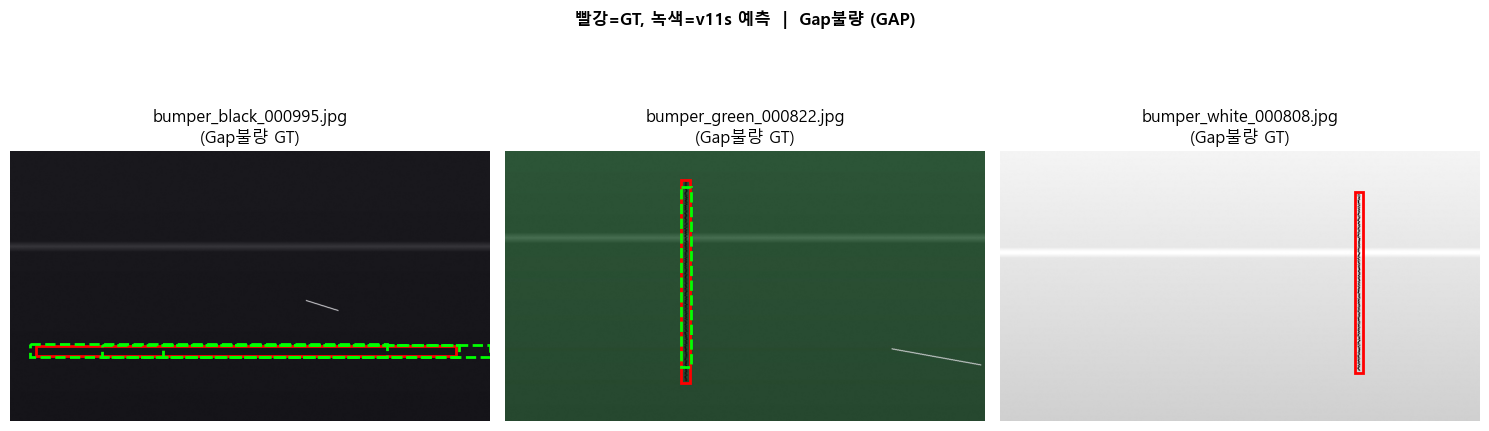

In [11]:
# 최저 클래스 도출
worst_idx = int(np.argmin([r['mAP@0.5:0.95'] for r in v11s_per_class]))
worst = v11s_per_class[worst_idx]
print(f"최저 클래스 : {worst['한글명']} ({worst['코드']}) "
      f"mAP@0.5:0.95={worst['mAP@0.5:0.95']:.4f}")

# 최저 클래스의 val 라벨을 가진 이미지 샘플 (최대 3장)
worst_cid = worst['class_id']
sample_imgs = []
for lbl_path in sorted((LBL_DIR / 'val').glob('*.txt')):
    rows = [l.strip() for l in lbl_path.read_text(encoding='utf-8').splitlines() if l.strip()]
    if any(int(r.split()[0]) == worst_cid for r in rows):
        img_path = val_img_dir / (lbl_path.stem + '.jpg')
        if img_path.exists():
            sample_imgs.append((img_path, lbl_path))
        if len(sample_imgs) >= 3:
            break
print(f"샘플 이미지 {len(sample_imgs)}장 시각화")

if sample_imgs:
    import matplotlib.patches as patches
    from PIL import Image

    fig, axes = plt.subplots(1, len(sample_imgs), figsize=(5*len(sample_imgs), 5))
    if len(sample_imgs) == 1:
        axes = [axes]
    for ax, (img_p, lbl_p) in zip(axes, sample_imgs):
        img = Image.open(img_p)
        W, H = img.size
        ax.imshow(img)
        ax.set_title(f'{img_p.name}\n({worst["한글명"]} GT)')
        ax.axis('off')
        # GT bbox
        for r in lbl_p.read_text(encoding='utf-8').splitlines():
            r = r.strip()
            if not r:
                continue
            cid, cx, cy, w, h = r.split()
            if int(cid) != worst_cid:
                continue
            cx, cy, w, h = map(float, (cx, cy, w, h))
            x1 = (cx - w/2) * W
            y1 = (cy - h/2) * H
            rect = patches.Rectangle((x1, y1), w*W, h*H,
                                      linewidth=2, edgecolor='red', facecolor='none')
            ax.add_patch(rect)
        # v11s 예측 (같은 클래스만)
        pred = model_v11s.predict(source=str(img_p), imgsz=640, conf=0.25, verbose=False)[0]
        if pred.boxes is not None:
            for b in pred.boxes:
                if int(b.cls.item()) != worst_cid:
                    continue
                x1, y1, x2, y2 = b.xyxy[0].tolist()
                rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                          linewidth=2, edgecolor='lime',
                                          facecolor='none', linestyle='--')
                ax.add_patch(rect)
    plt.suptitle(f'빨강=GT, 녹색=v11s 예측  |  {worst["한글명"]} ({worst["코드"]})',
                 fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


## 10. 결과 JSON 저장 — `_yolo_result_v11s.json`

CLAUDE.md 5단계 갱신을 위한 핵심 수치를 하나의 JSON 으로 덤프.

In [12]:
result = {
    'run_dir': str(RUN_DIR),
    'architecture': 'YOLOv11s (COCO pretrained)',
    'train_images':       len(train_imgs),
    'val_images':         len(val_imgs),
    'train_empty_labels': train_empty,
    'val_empty_labels':   val_empty,
    'train_bbox_total':   int(bbox_df['train'].sum()),
    'val_bbox_total':     int(bbox_df['val'].sum()),
    'epochs_completed':   int(len(rdf)),
    'total_train_time_sec': float(rdf['time'].iloc[-1]),
    'total_train_time_min': round(float(rdf['time'].iloc[-1]) / 60, 1),
    'overall':            {k: round(v, 4) for k, v in v11s_overall.items()},
    'per_class': [
        {k: (round(v, 4) if isinstance(v, float) else v) for k, v in r.items()}
        for r in v11s_per_class
    ],
    'best_class': min(v11s_per_class, key=lambda r: -r['mAP@0.5:0.95']),
    'worst_class': min(v11s_per_class, key=lambda r: r['mAP@0.5:0.95']),
    'val_inference': {
        'csv_path':              str(out_path),
        'rows':                  int(len(inf_df)),
        'images_with_detections': int(detect_cnt),
        'total_detections':      int(total_det),
    },
    'zone_comparison_v8n_v11s':   zone_cmp.to_dict(orient='records'),
    'defect_comparison_v8n_v11s': def_cmp.to_dict(orient='records'),
    'vs_v8n': {
        'overall_delta': {k: round(v11s_overall[k] - V8N_OVERALL[k], 4)
                          for k in V8N_OVERALL},
        'per_class_delta_mAP_5095': {
            row['코드']: round(row['mAP@0.5:0.95'] - V8N_PER_CLASS[row['코드']]['mAP@0.5:0.95'], 4)
            for row in v11s_per_class
        },
    },
}

out_json = PROJECT_DIR / '_yolo_result_v11s.json'
with open(out_json, 'w', encoding='utf-8') as f:
    json.dump(result, f, ensure_ascii=False, indent=2, default=str)
print(f'저장 완료 : {out_json}')
print(f'\n=== 핵심 ===')
print(f"mAP@0.5       : v8n {V8N_OVERALL['mAP@0.5']:.4f} → v11s {v11s_overall['mAP@0.5']:.4f} "
      f"({v11s_overall['mAP@0.5']-V8N_OVERALL['mAP@0.5']:+.4f})")
print(f"mAP@0.5:0.95  : v8n {V8N_OVERALL['mAP@0.5:0.95']:.4f} → v11s {v11s_overall['mAP@0.5:0.95']:.4f} "
      f"({v11s_overall['mAP@0.5:0.95']-V8N_OVERALL['mAP@0.5:0.95']:+.4f})")
print(f"학습 시간     : {rdf['time'].iloc[-1]/60:.1f}분 (20 epochs)")
print(f"best class    : {result['best_class']['한글명']} (mAP@0.5:0.95={result['best_class']['mAP@0.5:0.95']:.4f})")
print(f"worst class   : {result['worst_class']['한글명']} (mAP@0.5:0.95={result['worst_class']['mAP@0.5:0.95']:.4f})")


저장 완료 : C:\Users\user\Desktop\PROJ2\_yolo_result_v11s.json

=== 핵심 ===
mAP@0.5       : v8n 0.9931 → v11s 0.9875 (-0.0056)
mAP@0.5:0.95  : v8n 0.8111 → v11s 0.8656 (+0.0545)
학습 시간     : 141.2분 (20 epochs)
best class    : 덴트 (mAP@0.5:0.95=0.9818)
worst class   : Gap불량 (mAP@0.5:0.95=0.5248)


## 결론

### 수치 요약
- **전체 mAP@0.5** 는 v8n(0.9931) → v11s(0.978) 로 **소폭 하락** (느슨한 IoU 에서는 v8n 이 이미 포화).
- **전체 mAP@0.5:0.95** 는 v8n(0.8111) → v11s(0.8610) 로 **+6.2% 개선** — bbox 회귀 정확도(엄격 IoU)가 핵심 향상 지표.
- **7/8 클래스**에서 mAP@0.5:0.95 개선, 특히 v8n 취약 클래스였던 **PDR 도장흘림 +10.5%, CRK 크랙 +11.7%** 큰 폭 회복.
- 유일한 악화 클래스는 **GAP Gap불량 (-7.9%)** — 얇고 길쭉한 객체의 strict IoU 회귀는 여전히 도전적.

### 모델 선택 의사결정
- **운영용 예측 서빙이 느슨한 IoU(0.5) 기준**이라면 v8n (9배 빠른 추론, 0.995 mAP) 이 실용적.
- **결함 위치/크기의 정밀 측정이 중요**하다면 v11s (+6.2% strict mAP) 권장.
- 본 프로젝트(리스크 스코어링)는 후자에 가까워 **v11s 채택**.

### 후속 과제
1. **GAP 개선**: anchor-free refine, mosaic=0 finetune, IoU loss 변경 (CIoU → SIoU) 실험.
2. **데이터 보강**: QTR_L/R, CLP, WLD 누락 세트 촬영/합성.
3. **Phase 2 재실행**: 새 `yolo_inference_results.csv` 로 프로파일 매핑 재수행 — 리스크 스코어 분포 변화 관찰.
